<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/Examen_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Architecture Benchmark Predictivo Aplicado a Datos Climatológicos
### Predicción de lluvia al día siguiente en Australia mediante aprendizaje supervisado

**Maestría en Ciencia de Datos y Máquinas de Aprendizaje (CDyMA) — Universidad Técnica de Manabí**
**Asignatura:** Machine Learning
**Autora:** Ing. Madelayne Loor Vera

---

## Resumen (Abstract)

La predicción anticipada de lluvia es un problema de alto impacto para la agricultura, la logística y la gestión de riesgos ambientales. En este trabajo se aborda el problema de **clasificación binaria** de predecir si lloverá al día siguiente (`RainTomorrow`) a partir de observaciones meteorológicas diarias registradas en estaciones de toda Australia (dataset *Rain in Australia*, 145.460 registros, 2007–2017). Se diseñó un pipeline completo de Machine Learning que incluye limpieza de datos, imputación de valores nulos (comunes en sensores meteorológicos fallidos), ingeniería de características estacionales y escalado de variables. Se construyó un **Multi-Architecture Benchmark** comparando tres algoritmos de naturaleza distinta: **Regresión Logística**, **Random Forest** y **XGBoost**, evaluados mediante F1-Score, ROC-AUC y matrices de confusión debido al desbalance de clases (22% de días con lluvia). Los resultados muestran que los modelos de ensamble basados en árboles superan al modelo lineal base, siendo **XGBoost** el modelo ganador según ROC-AUC. El análisis de importancia de características reveló que la humedad a las 15:00 (`Humidity3pm`) es la variable más determinante para la predicción, seguida de la presión atmosférica y la nubosidad, resultado consistente con el conocimiento meteorológico de que la humedad ambiental es un precursor directo de la precipitación.

## 2. Metodología

### 2.1 Descripción de los Datos

El dataset utilizado es **Rain in Australia** (Kaggle: `jsphyg/weather-dataset-rattle-package`, fuente original: Australian Bureau of Meteorology), que contiene 145.460 observaciones diarias de estaciones meteorológicas de toda Australia entre 2007 y 2017. El archivo `weatherAUS.csv` se descarga directamente desde Kaggle.

**Variables principales:**

| Variable | Descripción |
|---|---|
| `MinTemp`, `MaxTemp` | Temperatura mínima y máxima (°C) |
| `Rainfall` | Precipitación registrada ese día (mm) |
| `Evaporation`, `Sunshine` | Evaporación (mm) y horas de sol |
| `WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm` | Velocidad del viento (km/h) |
| `Humidity9am`, `Humidity3pm` | Humedad relativa (%) a las 9am y 3pm |
| `Pressure9am`, `Pressure3pm` | Presión atmosférica (hPa) |
| `Cloud9am`, `Cloud3pm` | Nubosidad (octavos de cielo cubierto) |
| `Temp9am`, `Temp3pm` | Temperatura puntual (°C) |
| `RainToday` | Si llovió hoy (Sí/No) |
| **`RainTomorrow`** | **Variable objetivo:** ¿lloverá mañana? (Sí/No) |

> **Nota sobre fuga de datos (data leakage):** algunas versiones de este dataset incluyen una columna `RISK_MM` que representa la cantidad de lluvia del día siguiente — es decir, contiene directamente la respuesta. El notebook verifica su existencia y, si está presente, se **elimina explícitamente** antes de entrenar cualquier modelo.

### 2.2 Análisis Exploratorio (EDA) y Preprocesamiento

Se realiza limpieza de nulos (frecuentes por fallos de sensores), se descartan columnas con más de 35% de datos faltantes, se imputan las variables numéricas restantes con la mediana y las categóricas con la moda, se codifican variables categóricas, y se realiza **Feature Engineering** extrayendo el mes de la fecha para capturar la estacionalidad propia del clima australiano.

### 2.3 Diseño Experimental

Los datos se dividen en conjuntos de **entrenamiento (80%) y prueba (20%)**, de forma **estratificada** respecto a la variable objetivo para preservar la proporción de clases. Sobre el conjunto de entrenamiento se aplica **validación cruzada de 5 folds** para verificar la estabilidad del desempeño. Dado el desbalance de clases (~22% "Sí" vs. ~78% "No"), las métricas principales de evaluación son **F1-Score** y **ROC-AUC**, complementadas con la matriz de confusión, en lugar de depender únicamente de la Accuracy.


In [1]:
# ============================================================
# Importación de librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
except ImportError:
    %pip install -q xgboost
    from xgboost import XGBClassifier

RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ============================================================
# 2.1 Carga del dataset (descarga automática, sin credenciales de Kaggle)
# ============================================================
# Download latest version using kagglehub
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

print("Path to dataset files:", path)

# Construct the full path to the CSV file within the downloaded directory
csv_file_path = os.path.join(path, 'weatherAUS.csv')

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.
Path to dataset files: /kaggle/input/weather-dataset-rattle-package
Dimensiones del dataset: 145460 filas x 23 columnas


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# Eliminamos RISK_MM: contiene la cantidad de lluvia del día siguiente (fuga de datos)
if "RISK_MM" in df.columns:
    df = df.drop(columns=["RISK_MM"])

# Eliminamos filas sin variable objetivo
df = df.dropna(subset=["RainTomorrow"]).reset_index(drop=True)

print(f"Dimensiones tras eliminar RISK_MM y filas sin etiqueta: {df.shape}")
df["RainTomorrow"].value_counts(normalize=True).mul(100).round(1)


Dimensiones tras eliminar RISK_MM y filas sin etiqueta: (142193, 23)


,proportion
RainTomorrow,
No,77.6
Yes,22.4


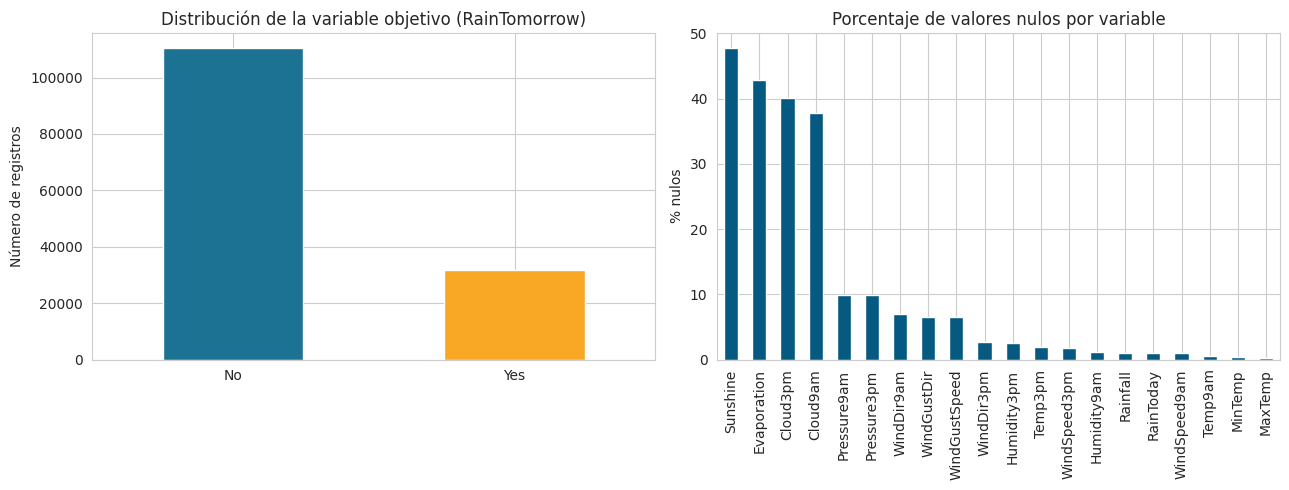

In [5]:
# ============================================================
# 2.2 Análisis Exploratorio (EDA)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución de la clase objetivo
df["RainTomorrow"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#1C7293", "#F9A826"]
)
axes[0].set_title("Distribución de la variable objetivo (RainTomorrow)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Número de registros")
axes[0].tick_params(axis="x", rotation=0)

# Porcentaje de nulos por columna
null_pct = df.isna().mean().sort_values(ascending=False) * 100
null_pct[null_pct > 0].plot(kind="bar", ax=axes[1], color="#065A82")
axes[1].set_title("Porcentaje de valores nulos por variable")
axes[1].set_ylabel("% nulos")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


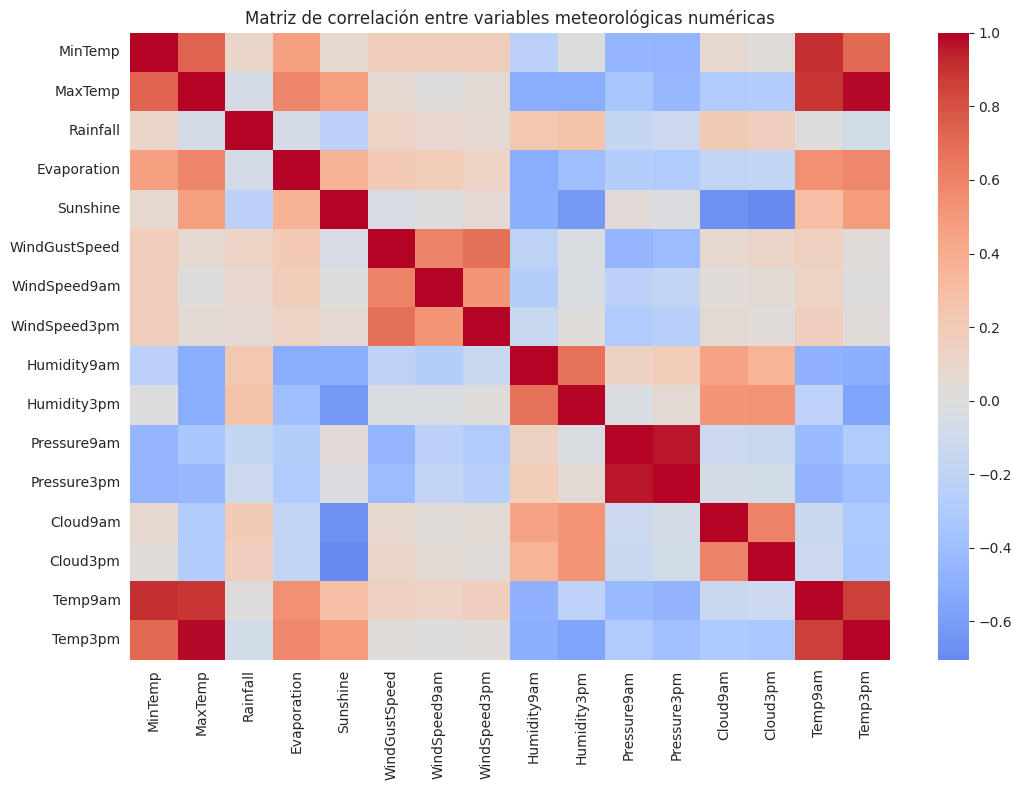

In [6]:
# Matriz de correlación de variables numéricas
plt.figure(figsize=(11, 8))
num_cols_preview = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols_preview].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables meteorológicas numéricas")
plt.tight_layout()
plt.show()
